## Project1 Spatial Transform

------------------------------
1次循环后 MSE (最近邻): 166.7169
1次循环后 MSE (双线性): 60.3928
------------------------------


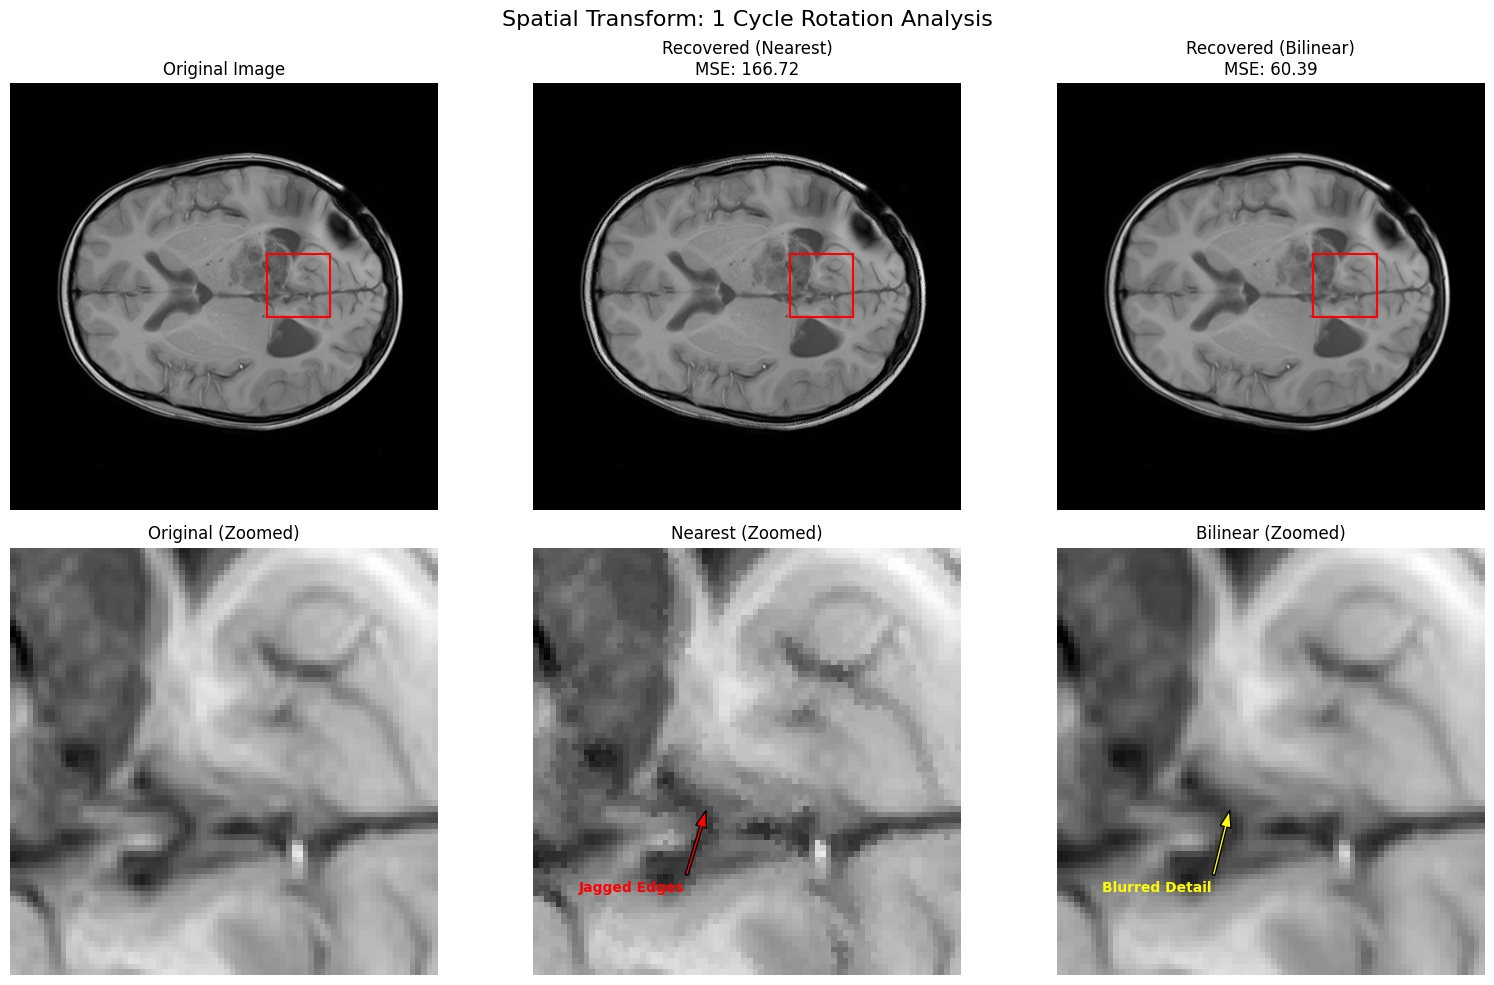

In [19]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def matrix_rotate(img, theta, method='nearest'):
    """
    使用矩阵运算旋转图像
    :param img: 输入图像 (2D numpy array)
    :param theta: 旋转角度 (弧度)
    :param method: 插值方法 ('nearest' 或 'bilinear')
    :return: 旋转后的图像
    """
    H, W = img.shape
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0 # 计算图像中心

    # 1. 生成目标图像的所有坐标点
    x = np.arange(W)
    y = np.arange(H)
    xx, yy = np.meshgrid(x, y)

    # 平移坐标系，使中心为原点
    xx_c = xx - cx
    yy_c = yy - cy

    # 展平坐标并堆叠成 2xN 矩阵，符合矩阵运算要求
    coords = np.vstack((xx_c.flatten(), yy_c.flatten()))

    # 2. 构建反向映射的旋转矩阵 R(-theta)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    R_inv = np.array([[cos_t, sin_t],
                      [-sin_t, cos_t]])

    # 3. 矩阵乘法计算原图坐标 (Matrix Operator)
    src_coords = R_inv @ coords

    # 平移回原坐标系并重塑为图像形状
    src_x = (src_coords[0, :] + cx).reshape(H, W)
    src_y = (src_coords[1, :] + cy).reshape(H, W)

    # 创建输出图像画布
    out_img = np.zeros_like(img, dtype=np.float32)

    # 标记在原图范围内的有效坐标点 (防止越界)
    valid = (src_x >= 0) & (src_x <= W - 1) & (src_y >= 0) & (src_y <= H - 1)

    # 4. 像素插值
    if method == 'nearest':
        # 最近邻插值：直接四舍五入取整
        src_x_round = np.round(src_x).astype(int)
        src_y_round = np.round(src_y).astype(int)
        out_img[valid] = img[src_y_round[valid], src_x_round[valid]]

    elif method == 'bilinear':
        # 双线性插值：获取周围四个像素点
        x0 = np.floor(src_x).astype(int)
        x1 = x0 + 1
        y0 = np.floor(src_y).astype(int)
        y1 = y0 + 1

        # 限制边界，防止索引溢出
        x0 = np.clip(x0, 0, W - 1)
        x1 = np.clip(x1, 0, W - 1)
        y0 = np.clip(y0, 0, H - 1)
        y1 = np.clip(y1, 0, H - 1)

        # 计算四个点的权重
        wa = (x1 - src_x) * (y1 - src_y)
        wb = (src_x - x0) * (y1 - src_y)
        wc = (x1 - src_x) * (src_y - y0)
        wd = (src_x - x0) * (src_y - y0)

        # 加权求和
        pixel_vals = (img[y0, x0] * wa + img[y0, x1] * wb + 
                      img[y1, x0] * wc + img[y1, x1] * wd)
        
        out_img[valid] = pixel_vals[valid]

    return out_img



# 1. 加载数据与参数设置
file_path = os.path.join('lab2_data', 'lab2_MRI.npy')
img = np.load(file_path)
theta = np.pi / 5

# 2. 执行单次旋转循环
# 最近邻插值
img_fwd_nn = matrix_rotate(img, theta, method='nearest')
img_rec_nn = matrix_rotate(img_fwd_nn, -theta, method='nearest')

# 双线性插值
img_fwd_bi = matrix_rotate(img, theta, method='bilinear')
img_rec_bi = matrix_rotate(img_fwd_bi, -theta, method='bilinear')

# 3. 量化差异 (Quantify differences)
def calculate_mse(original, recovered):
    # 仅计算非零区域（去除背景黑边的干扰）
    mask = original > 1e-5
    return np.mean((original[mask] - recovered[mask])**2)

mse_nn = calculate_mse(img, img_rec_nn)
mse_bi = calculate_mse(img, img_rec_bi)

print("-" * 30)
print(f"1次循环后 MSE (最近邻): {mse_nn:.4f}")
print(f"1次循环后 MSE (双线性): {mse_bi:.4f}")
print("-" * 30)

# 4. 可视化分析 (含误差图与局部放大)
# 设定放大区域 (ROI) 的坐标，这里假设图像特征在中央偏右，你可根据实际图像大小微调
H, W = img.shape
x1, y1, w_roi = int(W*0.6), int(H*0.4), int(W*0.15) 
x2, y2 = x1 + w_roi, y1 + w_roi

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Spatial Transform: 1 Cycle Rotation Analysis', fontsize=16)

# 第一排：恢复结果与差异图
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title("Original Image")

axes[0, 1].imshow(img_rec_nn, cmap='gray')
axes[0, 1].set_title(f"Recovered (Nearest)\nMSE: {mse_nn:.2f}")

axes[0, 2].imshow(img_rec_bi, cmap='gray')
axes[0, 2].set_title(f"Recovered (Bilinear)\nMSE: {mse_bi:.2f}")

# 在原图和恢复图上画出 ROI 红色方框
for ax in axes[0, :3]:
    rect = patches.Rectangle((x1, y1), w_roi, w_roi, linewidth=1.5, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.axis('off')

# 第二排：放大区域对比与高亮
# 原图放大
axes[1, 0].imshow(img[y1:y2, x1:x2], cmap='gray')
axes[1, 0].set_title("Original (Zoomed)")

# 最近邻放大 + 箭头
axes[1, 1].imshow(img_rec_nn[y1:y2, x1:x2], cmap='gray')
axes[1, 1].set_title("Nearest (Zoomed)")
# 使用箭头标出锯齿边缘
axes[1, 1].annotate('Jagged Edges', xy=(w_roi*0.4, w_roi*0.6), xytext=(w_roi*0.1, w_roi*0.8),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8), color='red', weight='bold')

# 双线性放大 + 箭头
axes[1, 2].imshow(img_rec_bi[y1:y2, x1:x2], cmap='gray')
axes[1, 2].set_title("Bilinear (Zoomed)")
# 使用箭头标出模糊细节
axes[1, 2].annotate('Blurred Detail', xy=(w_roi*0.4, w_roi*0.6), xytext=(w_roi*0.1, w_roi*0.8),
                    arrowprops=dict(facecolor='yellow', shrink=0.05, width=2, headwidth=8), color='yellow', weight='bold')

for ax in axes[1, :]:
    ax.axis('off')

plt.tight_layout()
plt.show()

发现大模型生成的区域是随机选定的区域，而并非通过计算得到的“差异显著的区域”。不过后来发现这两个对比图似乎也能反映一定的差异。但为了体现计算的过程还是使用算法来寻找差异比较显著的区域。

量化指标对比 (1次旋转循环):
最近邻插值 -> MSE: 166.7169
双线性插值 -> MSE: 60.3928
已自动锁定最大差异区域: 左上角坐标 (64, 128), 窗口大小 76x76


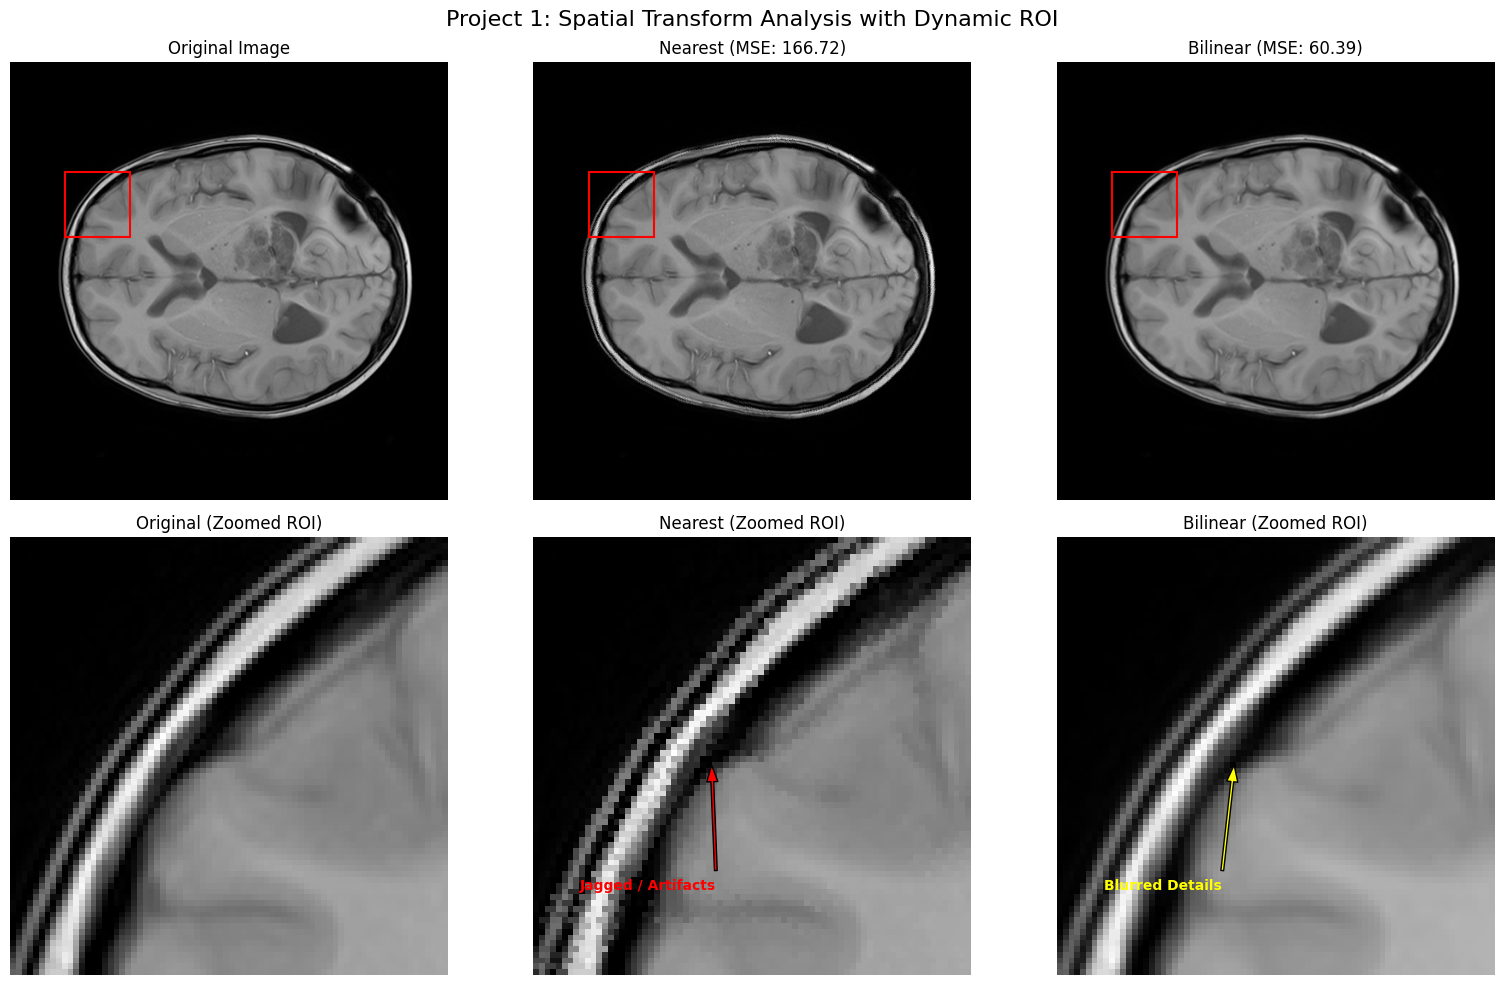

In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# 1. 核心矩阵运算函数 (Matrix Operator)
# ==========================================
def matrix_rotate(img, theta, method='nearest'):
    """
    使用矩阵运算实现图像的反向映射旋转
    """
    H, W = img.shape
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0 

    # 生成目标图像的所有坐标点网格
    x = np.arange(W)
    y = np.arange(H)
    xx, yy = np.meshgrid(x, y)

    # 平移坐标系，使中心为原点
    xx_c = xx - cx
    yy_c = yy - cy

    # 展平坐标并堆叠成 2xN 矩阵
    coords = np.vstack((xx_c.flatten(), yy_c.flatten()))

    # 构建反向映射的旋转矩阵 R(-theta)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    R_inv = np.array([[cos_t, sin_t],
                      [-sin_t, cos_t]])

    # 矩阵乘法计算原图坐标
    src_coords = R_inv @ coords

    # 平移回原坐标系并重塑为图像形状
    src_x = (src_coords[0, :] + cx).reshape(H, W)
    src_y = (src_coords[1, :] + cy).reshape(H, W)

    out_img = np.zeros_like(img, dtype=np.float32)

    # 标记在原图范围内的有效坐标点 (防止越界)
    valid = (src_x >= 0) & (src_x <= W - 1) & (src_y >= 0) & (src_y <= H - 1)

    if method == 'nearest':
        # 最近邻插值
        src_x_round = np.round(src_x).astype(int)
        src_y_round = np.round(src_y).astype(int)
        out_img[valid] = img[src_y_round[valid], src_x_round[valid]]

    elif method == 'bilinear':
        # 双线性插值
        x0 = np.floor(src_x).astype(int)
        x1 = x0 + 1
        y0 = np.floor(src_y).astype(int)
        y1 = y0 + 1

        x0 = np.clip(x0, 0, W - 1)
        x1 = np.clip(x1, 0, W - 1)
        y0 = np.clip(y0, 0, H - 1)
        y1 = np.clip(y1, 0, H - 1)

        wa = (x1 - src_x) * (y1 - src_y)
        wb = (src_x - x0) * (y1 - src_y)
        wc = (x1 - src_x) * (src_y - y0)
        wd = (src_x - x0) * (src_y - y0)

        pixel_vals = (img[y0, x0] * wa + img[y0, x1] * wb + 
                      img[y1, x0] * wc + img[y1, x1] * wd)
        
        out_img[valid] = pixel_vals[valid]

    return out_img

# ==========================================
# 2. 辅助分析函数 (误差计算 & 动态ROI寻找)
# ==========================================
def calculate_mse(original, recovered):
    """精确计算 MSE (去除黑色背景干扰)"""
    mask = original > 1e-5
    return np.mean((original[mask] - recovered[mask])**2)

def find_max_diff_roi(img1, img2, roi_size):
    """通过滑动窗口（均值滤波）自动寻找两张图像差异最大的区域"""
    diff = np.abs(img1 - img2)
    local_mean_diff = cv2.blur(diff, (roi_size, roi_size))
    _, _, _, max_loc = cv2.minMaxLoc(local_mean_diff)
    
    x_center, y_center = max_loc
    x1 = max(0, x_center - roi_size // 2)
    y1 = max(0, y_center - roi_size // 2)
    
    x1 = min(x1, img1.shape[1] - roi_size)
    y1 = min(y1, img1.shape[0] - roi_size)
    return x1, y1

# ==========================================
# 3. 实验主体执行：加载数据与变换
# ==========================================
file_path = os.path.join('lab2_data', 'lab2_MRI.npy')
img = np.load(file_path)
theta = np.pi / 5

# 执行 1 次旋转循环
img_fwd_nn = matrix_rotate(img, theta, method='nearest')
img_rec_nn = matrix_rotate(img_fwd_nn, -theta, method='nearest')

img_fwd_bi = matrix_rotate(img, theta, method='bilinear')
img_rec_bi = matrix_rotate(img_fwd_bi, -theta, method='bilinear')

mse_nn = calculate_mse(img, img_rec_nn)
mse_bi = calculate_mse(img, img_rec_bi)

print("=" * 45)
print("量化指标对比 (1次旋转循环):")
print(f"最近邻插值 -> MSE: {mse_nn:.4f}")
print(f"双线性插值 -> MSE: {mse_bi:.4f}")
print("=" * 45)

# ==========================================
# 4. 自动锁定差异并可视化
# ==========================================
H, W = img.shape
w_roi = int(W * 0.15)
x1, y1 = find_max_diff_roi(img, img_rec_nn, w_roi)
x2, y2 = x1 + w_roi, y1 + w_roi

print(f"已自动锁定最大差异区域: 左上角坐标 ({x1}, {y1}), 窗口大小 {w_roi}x{w_roi}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Project 1: Spatial Transform Analysis with Dynamic ROI', fontsize=16)

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title("Original Image")

axes[0, 1].imshow(img_rec_nn, cmap='gray')
axes[0, 1].set_title(f"Nearest (MSE: {mse_nn:.2f})")

axes[0, 2].imshow(img_rec_bi, cmap='gray')
axes[0, 2].set_title(f"Bilinear (MSE: {mse_bi:.2f})")

for ax in axes[0, :3]:
    rect = patches.Rectangle((x1, y1), w_roi, w_roi, linewidth=1.5, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.axis('off')

axes[1, 0].imshow(img[y1:y2, x1:x2], cmap='gray')
axes[1, 0].set_title("Original (Zoomed ROI)")

axes[1, 1].imshow(img_rec_nn[y1:y2, x1:x2], cmap='gray')
axes[1, 1].set_title("Nearest (Zoomed ROI)")
axes[1, 1].annotate('Jagged / Artifacts', xy=(w_roi*0.4, w_roi*0.5), xytext=(w_roi*0.1, w_roi*0.8),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8), color='red', weight='bold')

axes[1, 2].imshow(img_rec_bi[y1:y2, x1:x2], cmap='gray')
axes[1, 2].set_title("Bilinear (Zoomed ROI)")
axes[1, 2].annotate('Blurred Details', xy=(w_roi*0.4, w_roi*0.5), xytext=(w_roi*0.1, w_roi*0.8),
                    arrowprops=dict(facecolor='yellow', shrink=0.05, width=2, headwidth=8), color='yellow', weight='bold')

for ax in axes[1, :]:
    ax.axis('off')

plt.tight_layout()
plt.show()

正在计算 5 次连续旋转循环，请稍候...
----------------------------------------
信息损失对比 (1次 vs 5次循环):
最近邻 (Nearest): 1次 MSE = 166.7169  |  5次 MSE = 166.7173
双线性 (Bilinear): 1次 MSE = 60.3928  |  5次 MSE = 446.6971
----------------------------------------


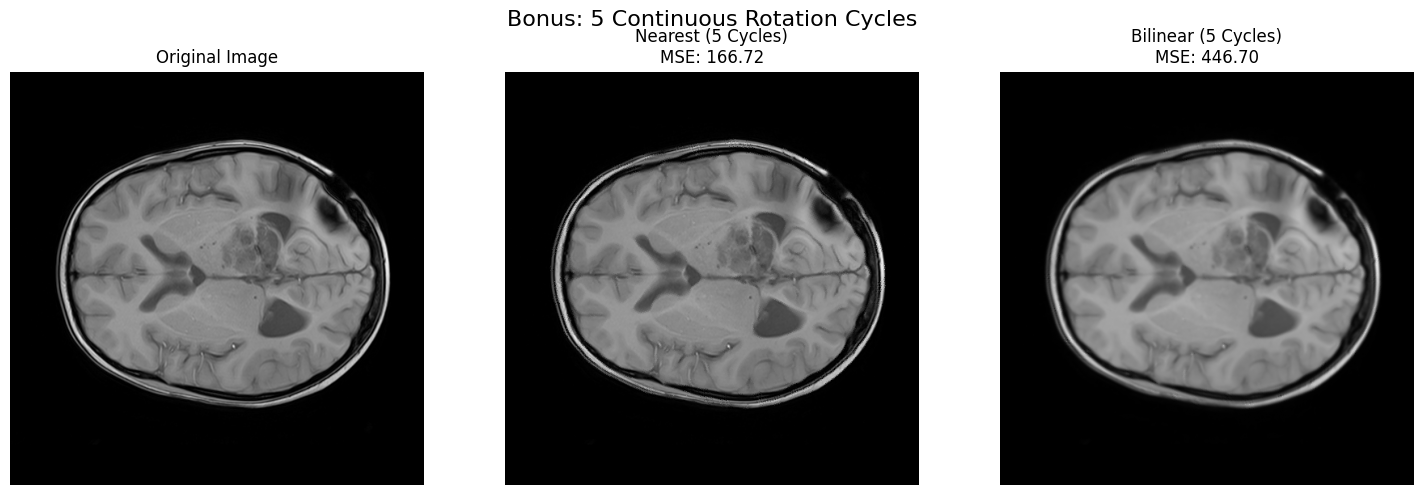

In [21]:
# ==========================================
# Bonus: 5次连续旋转循环信息损失对比
# ==========================================
img_bonus_nn = img.copy()
img_bonus_bi = img.copy()

print("正在计算 5 次连续旋转循环，请稍候...")
for i in range(5):
    img_bonus_nn = matrix_rotate(img_bonus_nn, theta, method='nearest')
    img_bonus_nn = matrix_rotate(img_bonus_nn, -theta, method='nearest')
    
    img_bonus_bi = matrix_rotate(img_bonus_bi, theta, method='bilinear')
    img_bonus_bi = matrix_rotate(img_bonus_bi, -theta, method='bilinear')

mse_nn_5 = calculate_mse(img, img_bonus_nn)
mse_bi_5 = calculate_mse(img, img_bonus_bi)

print("-" * 40)
print(f"信息损失对比 (1次 vs 5次循环):")
print(f"最近邻 (Nearest): 1次 MSE = {mse_nn:.4f}  |  5次 MSE = {mse_nn_5:.4f}")
print(f"双线性 (Bilinear): 1次 MSE = {mse_bi:.4f}  |  5次 MSE = {mse_bi_5:.4f}")
print("-" * 40)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Bonus: 5 Continuous Rotation Cycles', fontsize=16)

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")

axes[1].imshow(img_bonus_nn, cmap='gray')
axes[1].set_title(f"Nearest (5 Cycles)\nMSE: {mse_nn_5:.2f}")

axes[2].imshow(img_bonus_bi, cmap='gray')
axes[2].set_title(f"Bilinear (5 Cycles)\nMSE: {mse_bi_5:.2f}")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Project2 Intensity Transform

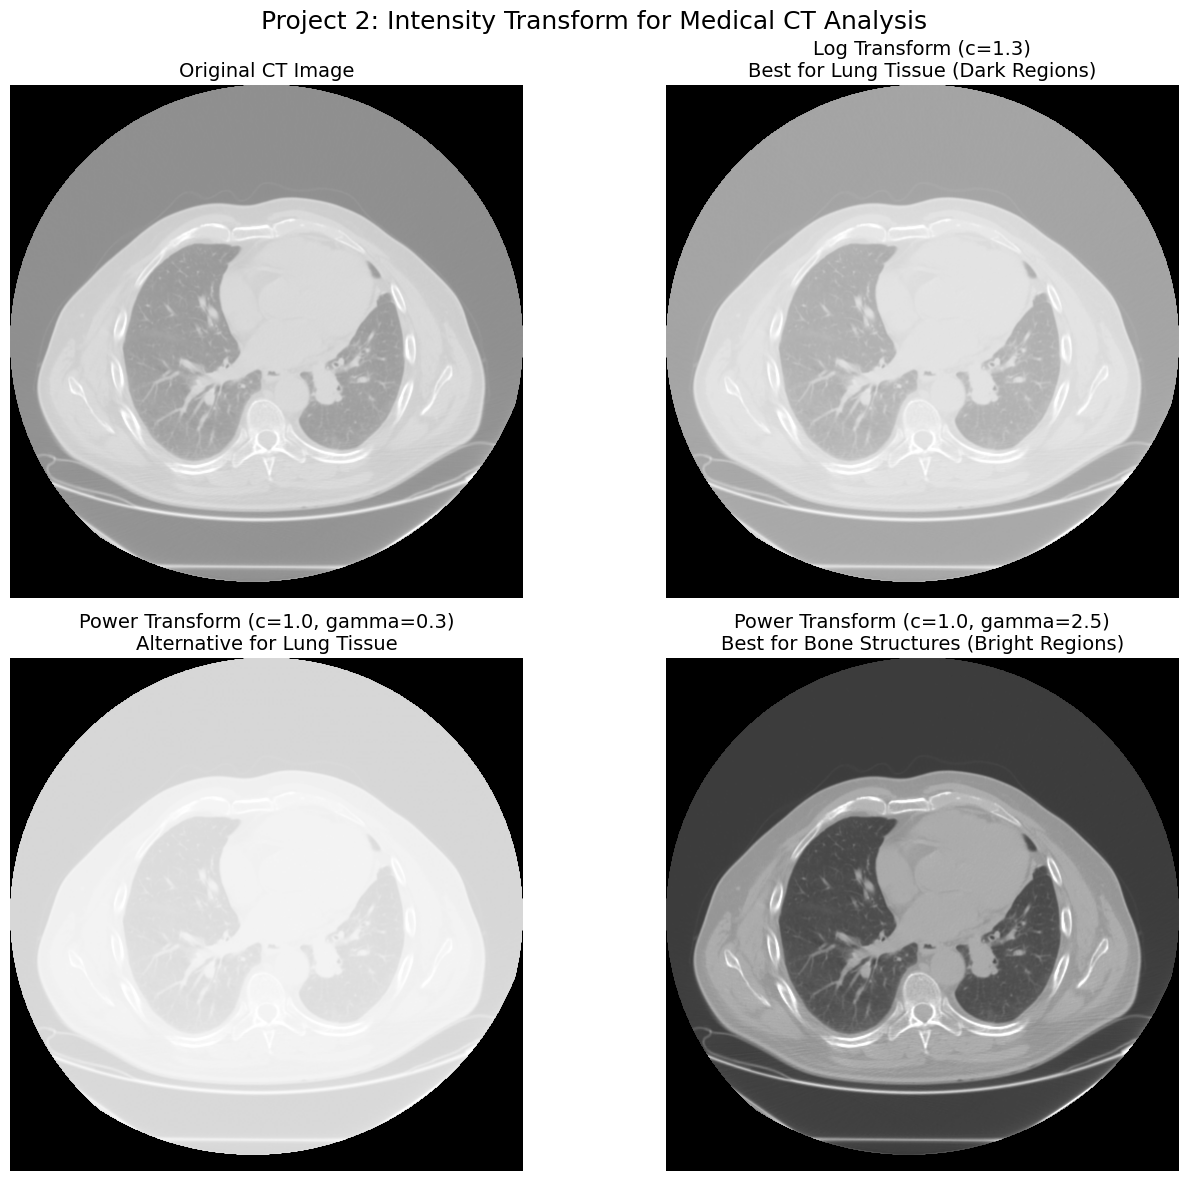

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 核心变换函数设计 (使用矩阵运算)
# ==========================================
def log_transform(img, c=1.0):
    """
    对数变换: s = c * log(1 + r)
    主要用于扩展低灰度区（暗部），压缩高灰度区（亮部）。
    """
    # 归一化到 [0, 1] 方便统一参数 c 的效果
    img_norm = (img - img.min()) / (img.max() - img.min())
    
    # 矩阵运算：利用 np.log1p 计算 log(1 + x)，防止 log(0) 报错
    img_log = c * np.log1p(img_norm)
    
    # 将结果截断在 [0, 1] 范围内
    return np.clip(img_log, 0, 1)

def power_transform(img, c=1.0, gamma=1.0):
    """
    幂律(Gamma)变换: s = c * r^gamma
    gamma < 1: 扩展暗部，压缩亮部
    gamma > 1: 压缩暗部，扩展亮部
    """
    img_norm = (img - img.min()) / (img.max() - img.min())
    
    # 矩阵运算：利用 np.power 直接对整个矩阵进行指数运算
    img_power = c * np.power(img_norm, gamma)
    
    return np.clip(img_power, 0, 1)

# ==========================================
# 2. 数据加载
# ==========================================
file_path = os.path.join('lab2_data', 'lab2_CT.npy')
img_ct = np.load(file_path)

# ==========================================
# 3. 针对不同医学结构的参数设计与变换
# ==========================================
# 目标 A：观察肺部组织 (Lung Tissue) - 肺部在 CT 中是暗区
# 策略：需要扩展低灰度区域
img_lung_log = log_transform(img_ct, c=1.3)          # 对数变换天生适合提亮暗部
img_lung_power = power_transform(img_ct, c=1.0, gamma=0.3) # 幂律变换 Gamma < 1 也能提亮暗部

# 目标 B：观察骨骼结构 (Bone Structures) - 骨骼在 CT 中是极亮区
# 策略：需要抑制暗部软组织，拉伸并对比高灰度区域
# 对数变换不适合此任务，因此仅使用幂律变换
img_bone_power = power_transform(img_ct, c=1.0, gamma=2.5) # 幂律变换 Gamma > 1 适合凸显亮部

# ==========================================
# 4. 可视化分析与结果展示
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Project 2: Intensity Transform for Medical CT Analysis', fontsize=18)

# 原始图像
axes[0, 0].imshow(img_ct, cmap='gray')
axes[0, 0].set_title('Original CT Image', fontsize=14)
axes[0, 0].axis('off')

# 观察肺部 - 对数变换
axes[0, 1].imshow(img_lung_log, cmap='gray')
axes[0, 1].set_title('Log Transform (c=1.3)\nBest for Lung Tissue (Dark Regions)', fontsize=14)
axes[0, 1].axis('off')

# 观察肺部 - 幂律变换 (Gamma < 1)
axes[1, 0].imshow(img_lung_power, cmap='gray')
axes[1, 0].set_title('Power Transform (c=1.0, gamma=0.3)\nAlternative for Lung Tissue', fontsize=14)
axes[1, 0].axis('off')

# 观察骨骼 - 幂律变换 (Gamma > 1)
axes[1, 1].imshow(img_bone_power, cmap='gray')
axes[1, 1].set_title('Power Transform (c=1.0, gamma=2.5)\nBest for Bone Structures (Bright Regions)', fontsize=14)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

大模型直接给我生成了他认为效果最好的参数及变化，缺乏对比过程。于是我根据要求重新生成了代码。

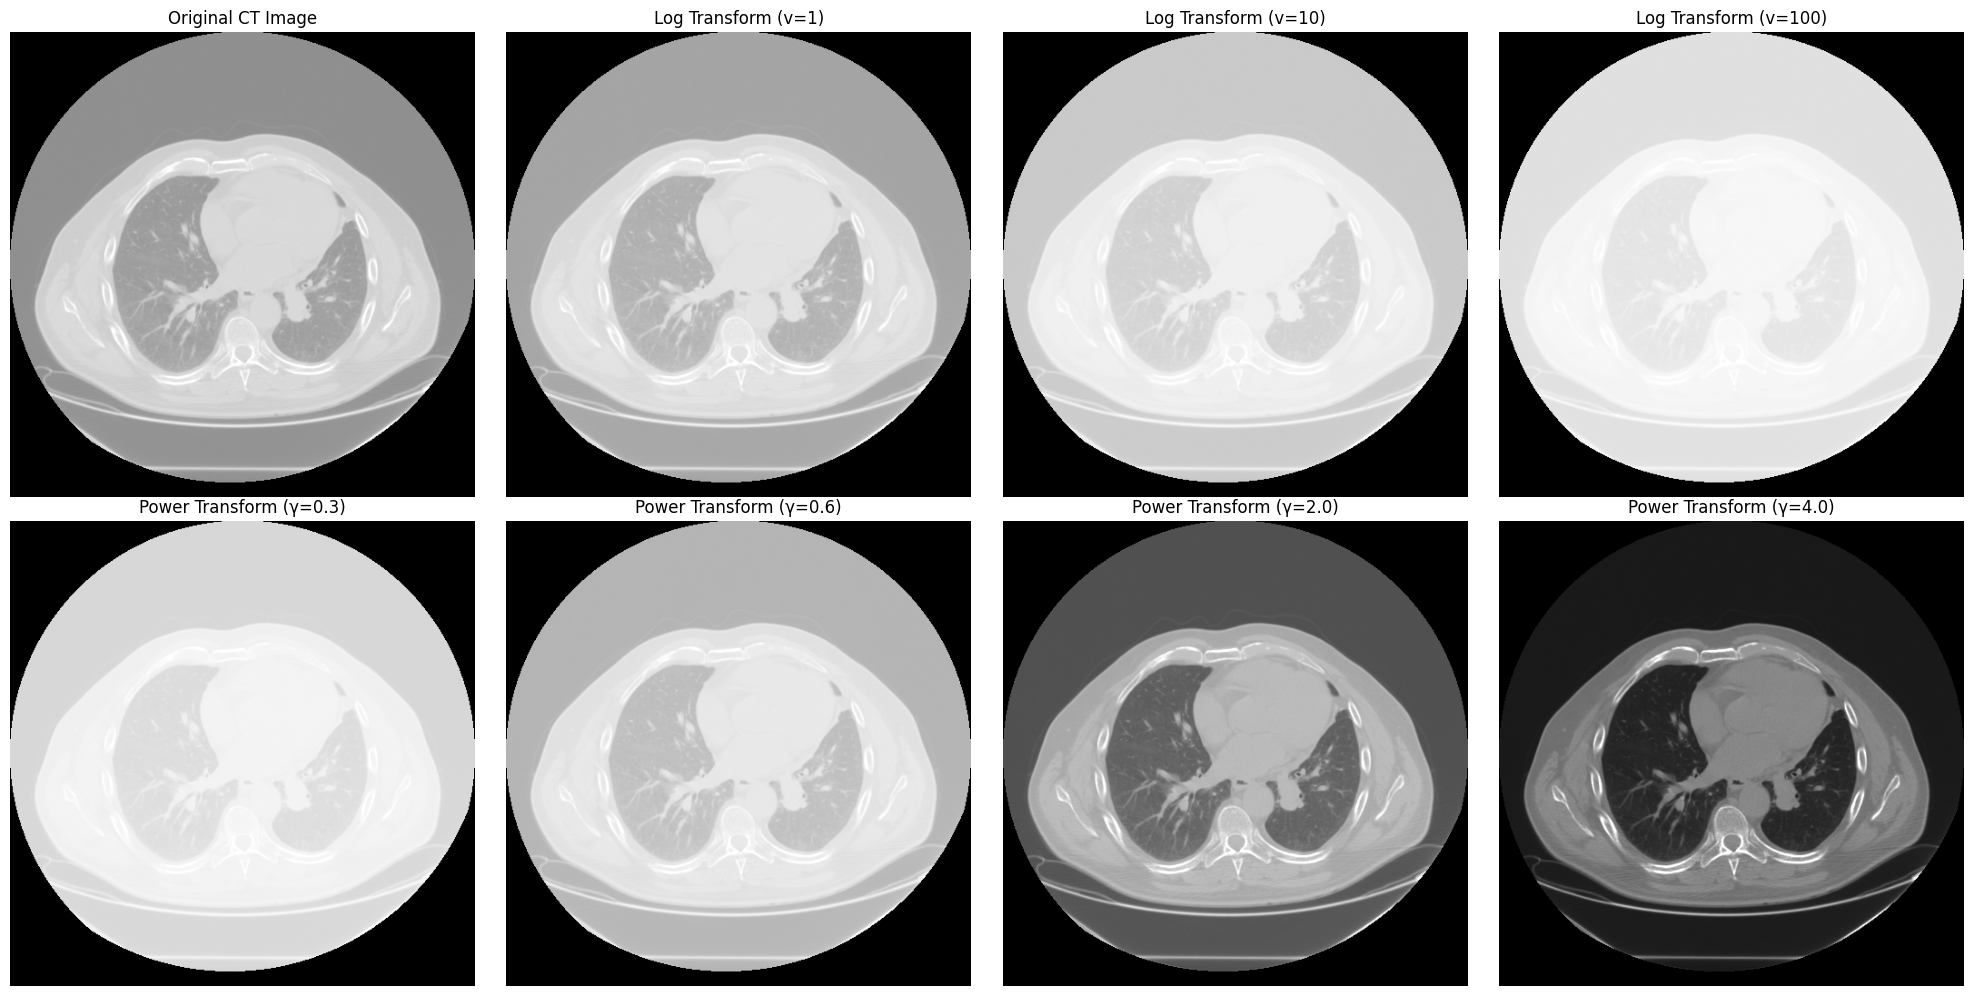

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 读取并归一化原始 CT 图像到 [0, 1] 区间
# 注意：文件路径已更新为 lab2_data 文件夹下
img_ct = np.load('lab2_data/lab2_CT.npy')
img_ct_norm = (img_ct - np.min(img_ct)) / (np.max(img_ct) - np.min(img_ct))

# 1. 探究对数变换参数 v 的影响
v_values = [1, 10, 100]  # v 越大，对数曲线在低灰度区的拉伸越剧烈
log_imgs = []
for v in v_values:
    # 计算归一化系数 c
    c_log = 1 / np.log(1 + v * np.max(img_ct_norm))
    # 矩阵运算实现参数化对数变换
    img_log = c_log * np.log(1 + v * img_ct_norm)
    log_imgs.append(img_log)

# 2. 探究幂律变换参数 gamma 的影响
gammas = [0.3, 0.6, 2.0, 4.0]
power_imgs = []
for gamma in gammas:
    c_power = 1 / np.power(np.max(img_ct_norm), gamma)
    img_power = c_power * np.power(img_ct_norm, gamma)
    power_imgs.append(img_power)

# 绘图展示所有参数对比
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# 第一行：原图与对数变换参数对比
axes[0, 0].imshow(img_ct_norm, cmap='gray')
axes[0, 0].set_title("Original CT Image")
axes[0, 1].imshow(log_imgs[0], cmap='gray')
axes[0, 1].set_title(f"Log Transform (v={v_values[0]})")
axes[0, 2].imshow(log_imgs[1], cmap='gray')
axes[0, 2].set_title(f"Log Transform (v={v_values[1]})")
axes[0, 3].imshow(log_imgs[2], cmap='gray')
axes[0, 3].set_title(f"Log Transform (v={v_values[2]})")

# 第二行：幂律变换参数对比
axes[1, 0].imshow(power_imgs[0], cmap='gray')
axes[1, 0].set_title(f"Power Transform (γ={gammas[0]})")
axes[1, 1].imshow(power_imgs[1], cmap='gray')
axes[1, 1].set_title(f"Power Transform (γ={gammas[1]})")
axes[1, 2].imshow(power_imgs[2], cmap='gray')
axes[1, 2].set_title(f"Power Transform (γ={gammas[2]})")
axes[1, 3].imshow(power_imgs[3], cmap='gray')
axes[1, 3].set_title(f"Power Transform (γ={gammas[3]})")

for ax in axes.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()

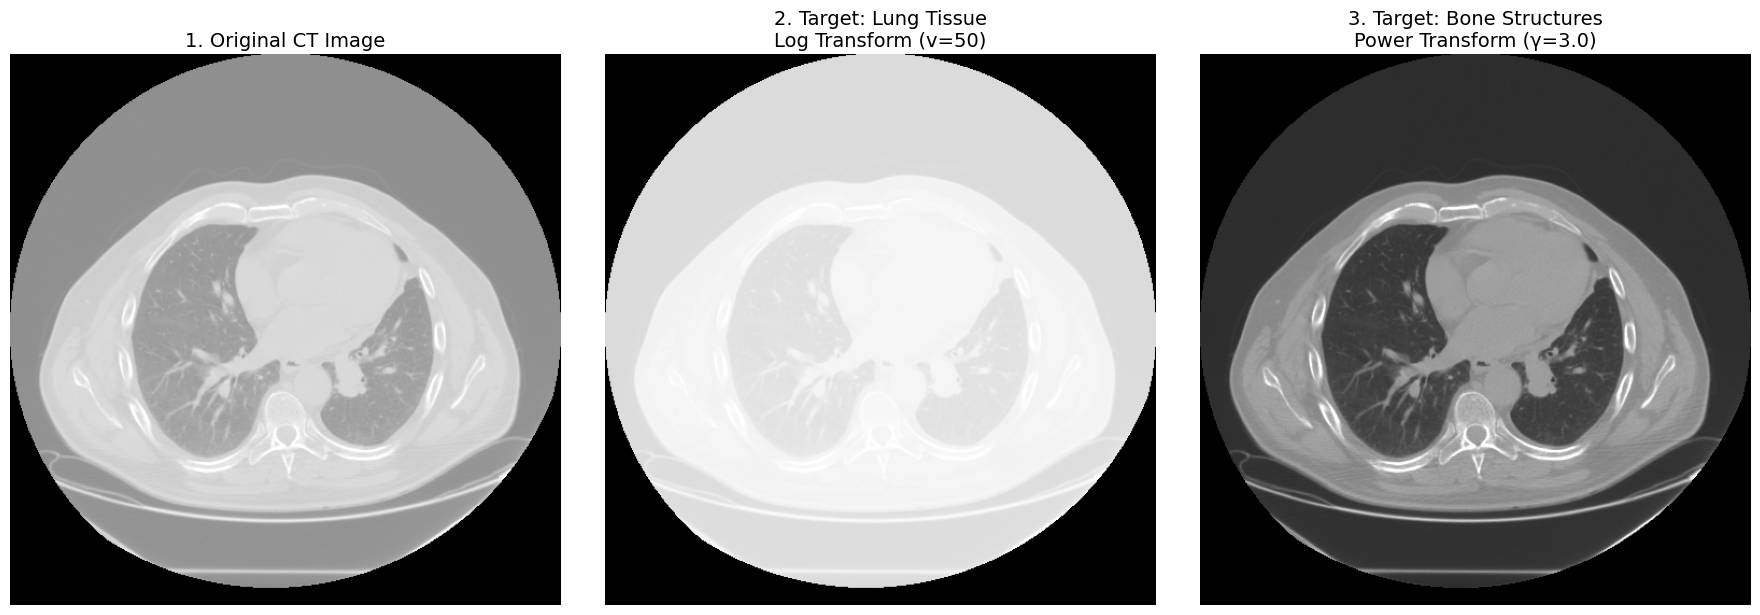

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 核心变换函数设计 (使用矩阵运算)
# ==========================================
def log_transform_v(img, v=1.0):
    """
    参数化对数变换: s = c * log(1 + v * r)
    参数 v 越大，对数曲线曲率越高，对暗部的拉伸越剧烈。
    """
    img_norm = (img - img.min()) / (img.max() - img.min())
    c = 1.0 / np.log1p(v) 
    img_log = c * np.log1p(v * img_norm)
    return np.clip(img_log, 0, 1)

def power_transform(img, gamma=1.0):
    """
    幂律(Gamma)变换: s = r^gamma
    """
    img_norm = (img - img.min()) / (img.max() - img.min())
    img_power = np.power(img_norm, gamma)
    return np.clip(img_power, 0, 1)

# ==========================================
# 2. 数据加载
# ==========================================
# 确保你的 lab2_CT.npy 文件存放在当前目录的 lab2_data 文件夹下
file_path = os.path.join('lab2_data', 'lab2_CT.npy')
img_ct = np.load(file_path)

# ==========================================
# 3. 特定组织的定向增强执行代码
# ==========================================

# 目标 A：肺部组织 (暗区拉伸) -> 使用高曲率对数变换
# v=50 能极大提升极暗区域的亮度，暴露出肺部微小纹理
img_lung_enhanced = log_transform_v(img_ct, v=50) 

# 目标 B：骨骼结构 (亮区拉伸) -> 使用高 Gamma 幂律变换
# gamma=3.0 的下凹曲线能压暗软组织背景，锐化高光骨骼区域的对比度
img_bone_enhanced = power_transform(img_ct, gamma=3.0) 

# ==========================================
# 4. 可视化结果展示
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_ct, cmap='gray')
axes[0].set_title('1. Original CT Image', fontsize=14)

axes[1].imshow(img_lung_enhanced, cmap='gray')
axes[1].set_title('2. Target: Lung Tissue\nLog Transform (v=50)', fontsize=14)

axes[2].imshow(img_bone_enhanced, cmap='gray')
axes[2].set_title('3. Target: Bone Structures\nPower Transform (γ=3.0)', fontsize=14)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Project 3 Spatial Filter: High pass filter

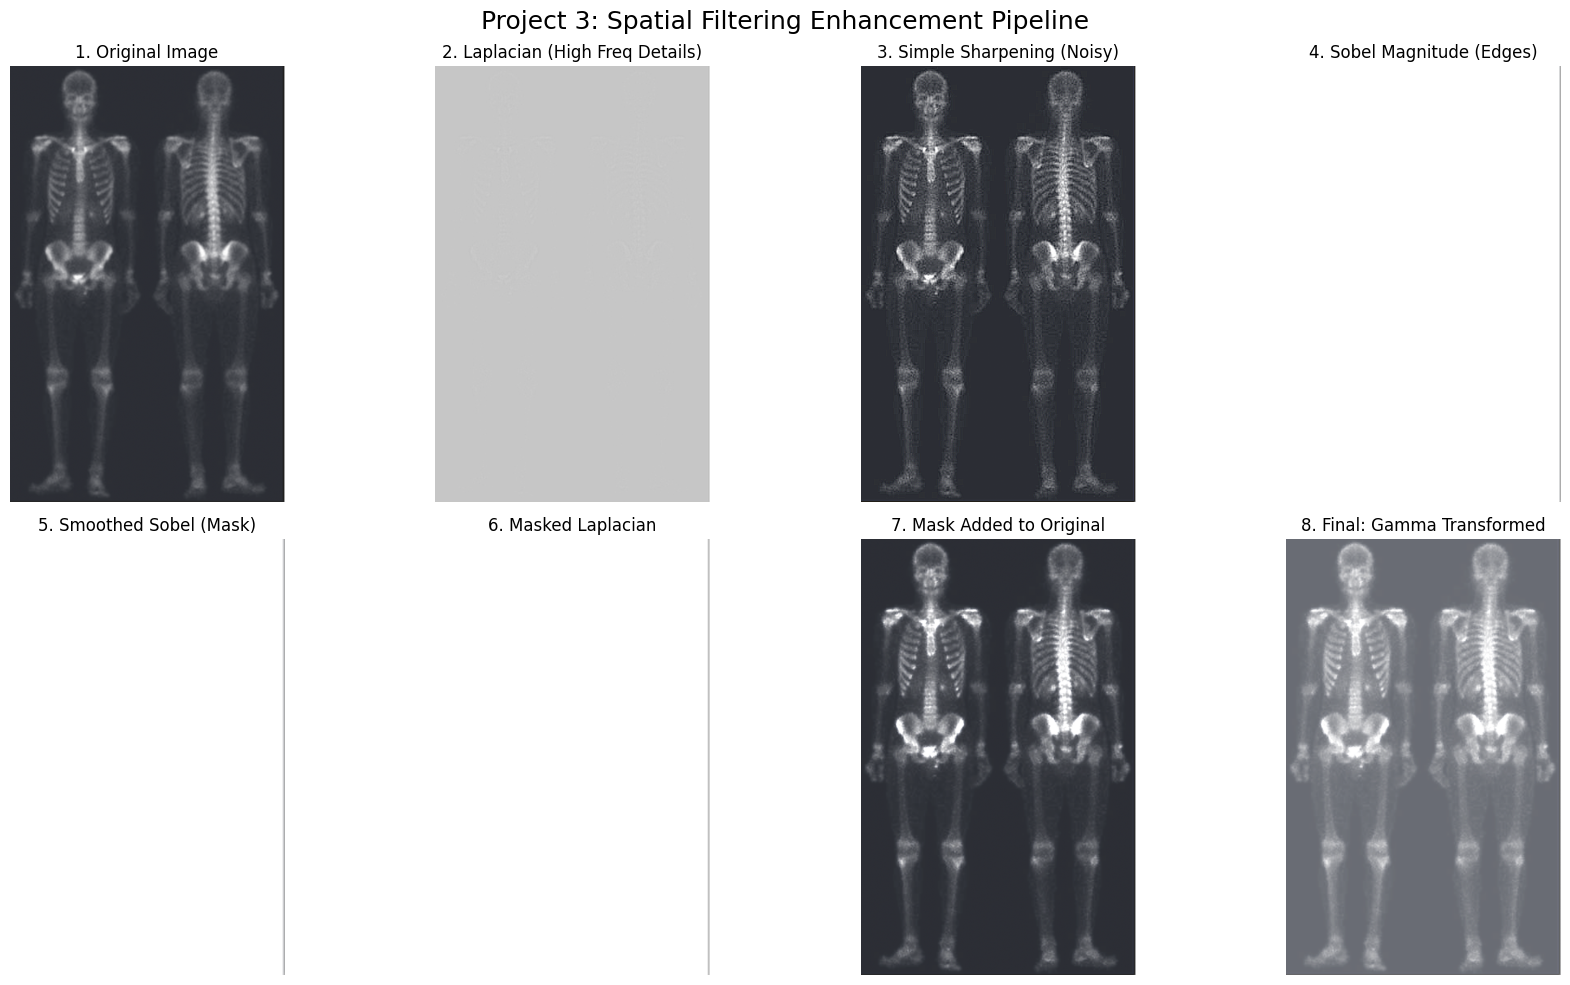

In [25]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 加载数据与归一化
# ==========================================
file_path = os.path.join('lab2_data', 'lab2_filter.npy')
img = np.load(file_path)

# 将图像归一化到 [0, 1]，这对于后续的矩阵乘法和幂运算非常重要
img = (img - img.min()) / (img.max() - img.min())

# ==========================================
# 2. 算子定义 (定义滤波矩阵)
# ==========================================
# 8-邻域拉普拉斯算子 (中心为正，提取高频细节)
laplacian_kernel = np.array([[-1, -1, -1],
                             [-1,  8, -1],
                             [-1, -1, -1]])

# Sobel 算子 (提取 X 和 Y 方向的梯度边缘)
sobel_x_kernel = np.array([[-1,  0,  1],
                           [-2,  0,  2],
                           [-1,  0,  1]])

sobel_y_kernel = np.array([[-1, -2, -1],
                           [ 0,  0,  0],
                           [ 1,  2,  1]])

# ==========================================
# 3. 核心滤波与增强管线 (The Enhancement Pipeline)
# ==========================================

# [Step A] 必做要求 1：8-邻域拉普拉斯滤波
# 作用：提取图像的二阶导数细节（非常精细的骨骼纹理，但会引入大量背景噪声）
laplacian_img = cv2.filter2D(img, -1, laplacian_kernel)
# 纯拉普拉斯锐化图像 (原图 + 拉普拉斯)
sharpened_img = np.clip(img + laplacian_img, 0, 1)

# [Step B] 必做要求 2：两个方向的 3x3 Sobel 滤波
# 作用：提取图像的一阶导数（提取出人体外轮廓和主要粗大骨骼边缘，对噪声不敏感）
sobel_x = cv2.filter2D(img, -1, sobel_x_kernel)
sobel_y = cv2.filter2D(img, -1, sobel_y_kernel)
# 计算 Sobel 梯度总幅值
sobel_mag = np.clip(np.abs(sobel_x) + np.abs(sobel_y), 0, 1)

# [Step C] 自主设计 1：Sobel 平滑掩膜 (5x5 均值滤波)
# 作用：将 Sobel 提取出的强边缘模糊化，制作成一个“权重掩膜 (Weight Mask)”
box_kernel = np.ones((5, 5)) / 25
sobel_smoothed = cv2.filter2D(sobel_mag, -1, box_kernel)

# [Step D] 自主设计 2：掩膜相乘 (Masking)
# 作用：将拉普拉斯锐化图(A) 与 Sobel掩膜(C) 相乘。
# 核心原理：在强边缘处保留拉普拉斯的锐化细节；在无边缘的平坦区（背景），因为掩膜趋于黑(0)，从而压制了拉普拉斯带来的噪声！
masked_sharpened = sharpened_img * sobel_smoothed

# [Step E] 自主设计 3：最终融合
# 作用：将降噪后的精细锐化细节加回原始图像
enhanced_img = np.clip(img + masked_sharpened, 0, 1)

# [Step F] 自主设计 4：利用 Project 2 的经验，进行 Gamma 对比度增强
# 作用：整体提亮图像，凸显骨骼，拉开动态范围
gamma = 0.5
final_result = np.power(enhanced_img, gamma)

# ==========================================
# 4. 可视化分析展示 (已修复越界警告)
# ==========================================
def norm_for_display(image):
    """
    专为显示设计的归一化函数：
    将任意范围的矩阵映射回 [0, 1]，防止 imshow 报错
    """
    return (image - image.min()) / (image.max() - image.min() + 1e-8)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Project 3: Spatial Filtering Enhancement Pipeline', fontsize=18)

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title("1. Original Image")

# 拉普拉斯本身包含负数，需要用 norm_for_display 处理后展示
axes[0, 1].imshow(norm_for_display(laplacian_img), cmap='gray')
axes[0, 1].set_title("2. Laplacian (High Freq Details)")

axes[0, 2].imshow(sharpened_img, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title("3. Simple Sharpening (Noisy)")

# Sobel 幅值可能超出 1，为了安全也进行归一化
axes[0, 3].imshow(norm_for_display(sobel_mag), cmap='gray')
axes[0, 3].set_title("4. Sobel Magnitude (Edges)")

axes[1, 0].imshow(norm_for_display(sobel_smoothed), cmap='gray')
axes[1, 0].set_title("5. Smoothed Sobel (Mask)")

# 掩膜相乘后的结果可能会略微超出 1，进行归一化
axes[1, 1].imshow(norm_for_display(masked_sharpened), cmap='gray')
axes[1, 1].set_title("6. Masked Laplacian")

axes[1, 2].imshow(enhanced_img, cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title("7. Mask Added to Original")

axes[1, 3].imshow(final_result, cmap='gray', vmin=0, vmax=1)
axes[1, 3].set_title("8. Final: Gamma Transformed")

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

该代码存在问题，2，4，5，6的图片都未能正常显示。询问AI后发现是由于原数据可能是包含 RGB/RGBA 多通道的 3D 矩阵，导致导数算子(Sobel/Laplacian)作用于全为 1 的透明度通道时产生 0 值。

修复：强制判断维度，若是 3 维则只提取第 0 个通道，转换为纯粹的 2D 灰度图。

以及matplotlib imshow 的 Clipping 越界警告，是由于拉普拉斯和 Sobel 提取的导数包含了负数或大于 1 的极大值。

修复：设计一个专用于展示的归一化函数，仅在画图前将矩阵等比压缩到 [0, 1]。

检测到输入图像为 3 维矩阵，正在提取单通道灰度数据...


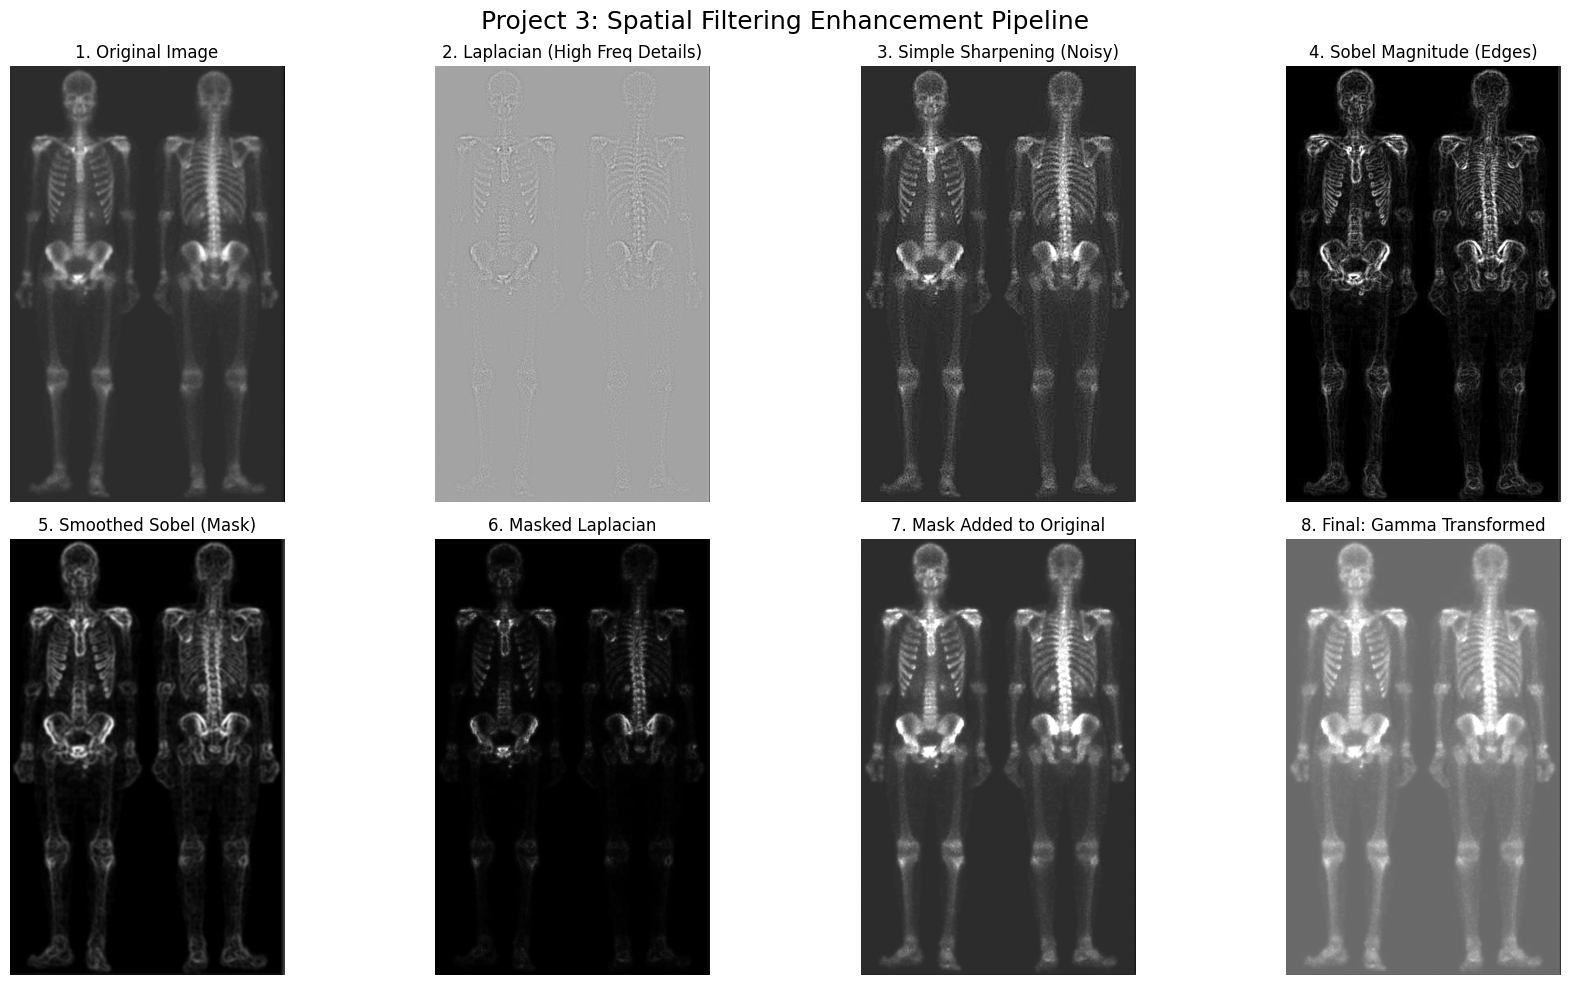

In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 加载数据与预处理 (包含维度修复)
# ==========================================
file_path = os.path.join('lab2_data', 'lab2_filter.npy')
img = np.load(file_path)

# 【修复点 1：解决中间步骤输出白图/灰图的 Bug】
# 原因：发现原数据可能是包含 RGB/RGBA 多通道的 3D 矩阵，
# 导致导数算子(Sobel/Laplacian)作用于全为 1 的透明度通道时产生 0 值。
# 修复：强制判断维度，若是 3 维则只提取第 0 个通道，转换为纯粹的 2D 灰度图。
if img.ndim == 3:
    print(f"检测到输入图像为 {img.ndim} 维矩阵，正在提取单通道灰度数据...")
    img = img[:, :, 0]

# 将图像归一化到 [0, 1]，为后续矩阵运算和 Gamma 变换做准备
img = (img - img.min()) / (img.max() - img.min())

# ==========================================
# 2. 算子定义 (定义滤波矩阵)
# ==========================================
# 8-邻域拉普拉斯算子 (提取高频细节)
laplacian_kernel = np.array([[-1, -1, -1],
                             [-1,  8, -1],
                             [-1, -1, -1]])

# Sobel 算子 (提取 X 和 Y 方向的梯度边缘)
sobel_x_kernel = np.array([[-1,  0,  1],
                           [-2,  0,  2],
                           [-1,  0,  1]])

sobel_y_kernel = np.array([[-1, -2, -1],
                           [ 0,  0,  0],
                           [ 1,  2,  1]])

# ==========================================
# 3. 核心滤波与增强管线 (The Enhancement Pipeline)
# ==========================================
# [Step A] 8-邻域拉普拉斯滤波
laplacian_img = cv2.filter2D(img, -1, laplacian_kernel)
sharpened_img = np.clip(img + laplacian_img, 0, 1)

# [Step B] 两个方向的 3x3 Sobel 滤波
sobel_x = cv2.filter2D(img, -1, sobel_x_kernel)
sobel_y = cv2.filter2D(img, -1, sobel_y_kernel)
sobel_mag = np.clip(np.abs(sobel_x) + np.abs(sobel_y), 0, 1)

# [Step C] Sobel 平滑掩膜 (5x5 均值滤波)
box_kernel = np.ones((5, 5)) / 25
sobel_smoothed = cv2.filter2D(sobel_mag, -1, box_kernel)

# [Step D] 掩膜相乘 (Masking：在骨骼处保留拉普拉斯细节，在背景处压制噪声)
masked_sharpened = sharpened_img * sobel_smoothed

# [Step E] 最终融合 (加回原图)
enhanced_img = np.clip(img + masked_sharpened, 0, 1)

# [Step F] Gamma 对比度增强 (整体提亮，拉开动态范围)
gamma = 0.5
final_result = np.power(enhanced_img, gamma)

# ==========================================
# 4. 可视化分析展示 (包含越界警告修复)
# ==========================================

# 【修复点 2：解决 matplotlib imshow 的 Clipping 越界警告】
# 原因：拉普拉斯和 Sobel 提取的导数包含了负数或大于 1 的极大值。
# 修复：设计一个专用于展示的归一化函数，仅在画图前将矩阵等比压缩到 [0, 1]。
def norm_for_display(image):
    return (image - image.min()) / (image.max() - image.min() + 1e-8)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Project 3: Spatial Filtering Enhancement Pipeline', fontsize=18)

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title("1. Original Image")

# 包含负数，调用 norm_for_display
axes[0, 1].imshow(norm_for_display(laplacian_img), cmap='gray')
axes[0, 1].set_title("2. Laplacian (High Freq Details)")

axes[0, 2].imshow(sharpened_img, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title("3. Simple Sharpening (Noisy)")

# 导数极值可能越界，调用 norm_for_display
axes[0, 3].imshow(norm_for_display(sobel_mag), cmap='gray')
axes[0, 3].set_title("4. Sobel Magnitude (Edges)")

axes[1, 0].imshow(norm_for_display(sobel_smoothed), cmap='gray')
axes[1, 0].set_title("5. Smoothed Sobel (Mask)")

# 掩膜相乘结果调用 norm_for_display
axes[1, 1].imshow(norm_for_display(masked_sharpened), cmap='gray')
axes[1, 1].set_title("6. Masked Laplacian")

axes[1, 2].imshow(enhanced_img, cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title("7. Mask Added to Original")

axes[1, 3].imshow(final_result, cmap='gray', vmin=0, vmax=1)
axes[1, 3].set_title("8. Final: Gamma Transformed")

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

图6算法错误，在AI指导下更正了算法。

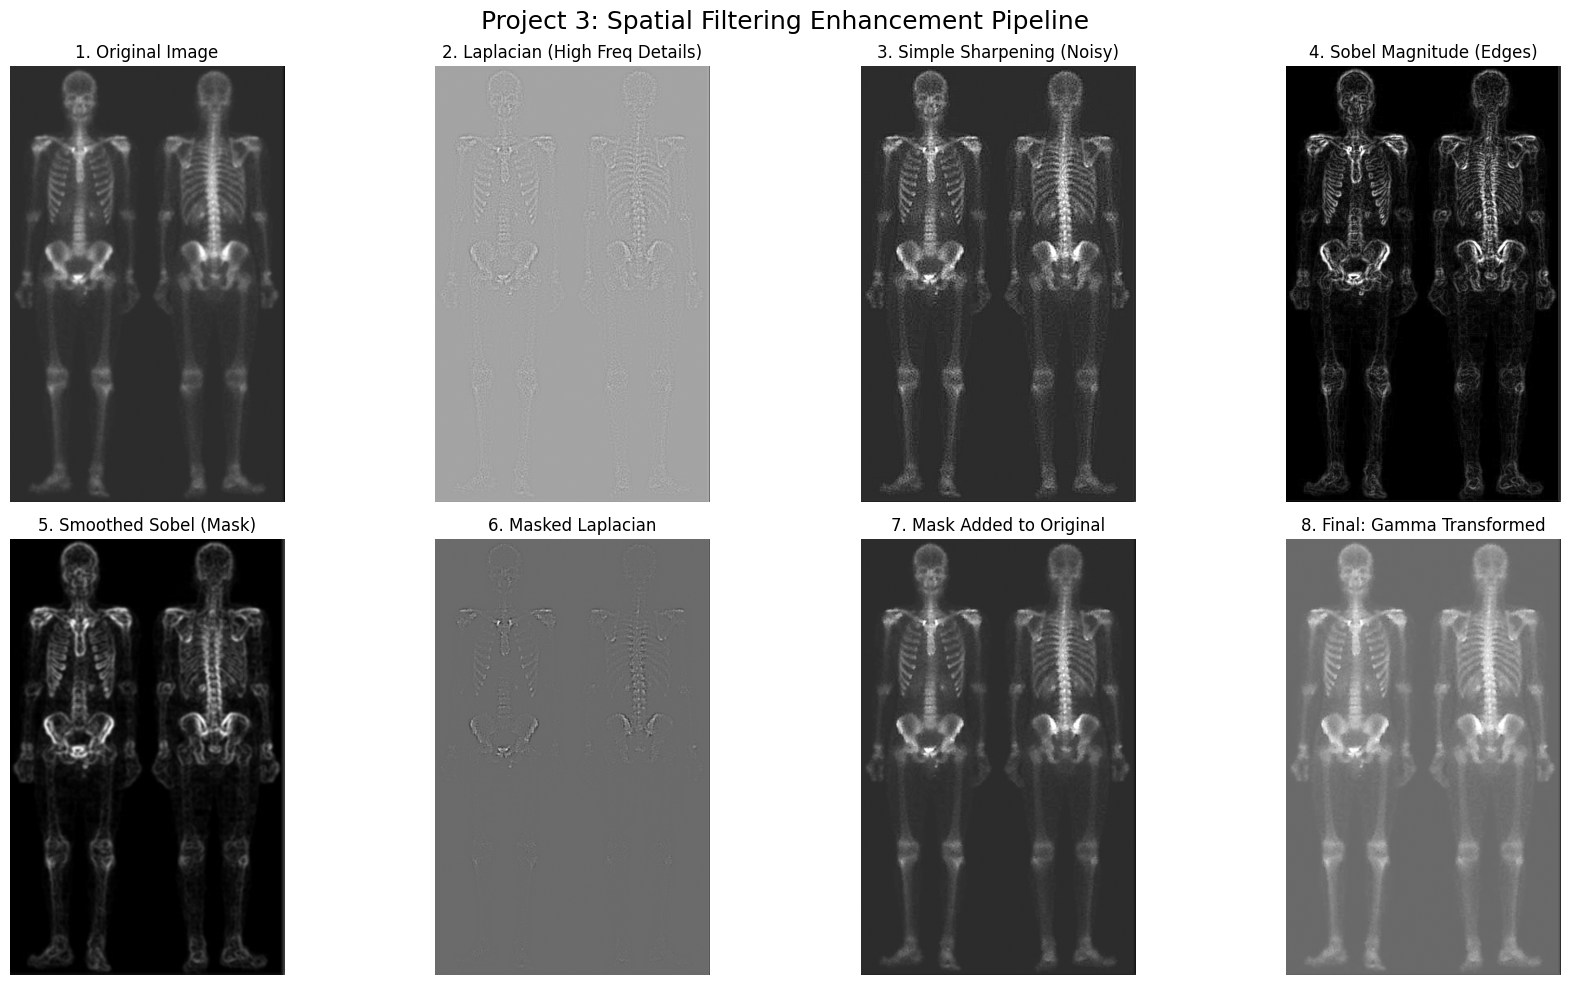

In [27]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 加载数据与预处理
# ==========================================
file_path = os.path.join('lab2_data', 'lab2_filter.npy')
img = np.load(file_path)

if img.ndim == 3:
    img = img[:, :, 0]
img = (img - img.min()) / (img.max() - img.min())

# ==========================================
# 2. 算子定义
# ==========================================
laplacian_kernel = np.array([[-1, -1, -1],
                             [-1,  8, -1],
                             [-1, -1, -1]])

sobel_x_kernel = np.array([[-1,  0,  1],
                           [-2,  0,  2],
                           [-1,  0,  1]])
sobel_y_kernel = np.array([[-1, -2, -1],
                           [ 0,  0,  0],
                           [ 1,  2,  1]])

# ==========================================
# 3. 核心滤波与增强管线 (修复后的经典管线)
# ==========================================
# [Step A] Laplacian (提取细节，包含正负值和噪声)
laplacian_img = cv2.filter2D(img, -1, laplacian_kernel)

# [Step B] Simple Sharpening (初级锐化，仅做反面教材展示)
sharpened_img = np.clip(img + laplacian_img, 0, 1)

# [Step C] Sobel (提取真实边缘)
sobel_x = cv2.filter2D(img, -1, sobel_x_kernel)
sobel_y = cv2.filter2D(img, -1, sobel_y_kernel)
sobel_mag = np.clip(np.abs(sobel_x) + np.abs(sobel_y), 0, 1)

# [Step D] Smoothed Sobel (平滑掩膜)
box_kernel = np.ones((5, 5)) / 25
sobel_smoothed = cv2.filter2D(sobel_mag, -1, box_kernel)

# [Step E] 掩膜相乘 (应该用纯细节去乘掩膜，过滤掉背景细节噪声)
masked_laplacian = laplacian_img * sobel_smoothed

# [Step F] 最终融合 (将过滤后的干净细节加回原图)
enhanced_img = np.clip(img + masked_laplacian, 0, 1)

# [Step G] Gamma 对比度增强
gamma = 0.5
final_result = np.power(enhanced_img, gamma)

# ==========================================
# 4. 可视化分析展示
# ==========================================
def norm_for_display(image):
    # 将含有负数的矩阵居中归一化，0会变成0.5(灰色)
    return (image - image.min()) / (image.max() - image.min() + 1e-8)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Project 3: Spatial Filtering Enhancement Pipeline', fontsize=18)

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title("1. Original Image")

axes[0, 1].imshow(norm_for_display(laplacian_img), cmap='gray')
axes[0, 1].set_title("2. Laplacian (High Freq Details)")

axes[0, 2].imshow(sharpened_img, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title("3. Simple Sharpening (Noisy)")

axes[0, 3].imshow(norm_for_display(sobel_mag), cmap='gray')
axes[0, 3].set_title("4. Sobel Magnitude (Edges)")

axes[1, 0].imshow(norm_for_display(sobel_smoothed), cmap='gray')
axes[1, 0].set_title("5. Smoothed Sobel (Mask)")

# 过滤后的纯净细节
axes[1, 1].imshow(norm_for_display(masked_laplacian), cmap='gray')
axes[1, 1].set_title("6. Masked Laplacian")

axes[1, 2].imshow(enhanced_img, cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title("7. Mask Added to Original")

axes[1, 3].imshow(final_result, cmap='gray', vmin=0, vmax=1)
axes[1, 3].set_title("8. Final: Gamma Transformed")

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()